## Парсинг и сборка датасета финансовых компаний с последующим анализом данных и подсчётом статистических метрик.

In [6]:
%%time
global get_inn, get_org_id, create_session, extract_financials, build_dataframe, analys_for_growth, build_counts_data, graph_plotting, distribution_ebit_graph, median_ebit_graph
from parsing import get_inn, get_org_id, create_session, extract_financials, build_dataframe, analys_for_growth, build_counts_data, graph_plotting, distribution_ebit_graph, median_ebit_graph

CPU times: total: 0 ns
Wall time: 26.7 μs


### 1) Агрегация данных.

Подготавливаем данные для парсинга. Извлекаем малые и средние предприятия с типом субъекта юридическое лицо, основной вид деятельности начинаается с кода 41.20.

### 2) Парсинг сайта bo.nalog.gov.ru

In [8]:
%%time

inn_data = get_inn()
session = create_session()

result = []
total = len(inn_data)
for count, inn in enumerate(inn_data, 1):
    try:
        org_id = get_org_id(session, inn)
        company_fin = extract_financials(session, org_id, inn)
        if company_fin:
            result.append(company_fin)
    except requests.RequestException as e:
        continue

    except (ValueError, KeyError, TypeError, IndexError) as e:
        continue

if not result:
    pring("Не удалось собрать данные ни по одной компании. Работа прервана.")
    sys.exit(1)

print(f"Сбор завершён. Успешно получены данные по {len(result)} компаниям из {total}.")
print(f"Пропущено из-за ошибок или отсутствия данных: {total - len(result)}")

CPU times: total: 188 ms
Wall time: 940 ms


NameError: name 'requests' is not defined

## 3) Построение датафрейма и анализ данных.

In [ ]:
df_results = build_dataframe(result)

NameError: name 'result' is not defined

#### Обноснование метрики (EBITA):
В качестве ключевого показателя используется EBITA (Earnings Before Interest, Taxes, and Amortization — прибыль до вычета процентов, налогов и амортизации). Для строительной отрасли это критически важная метрика. Строительство отличается высокой капиталоемкостью и сильной зависимостью от заемных средств (проектное финансирование, кредитные линии). У разных МСП могут кардинально различаться налоговые режимы и стоимость долга. EBITA позволяет «очистить» финансовый результат от структуры капитала и оценить чистую операционную эффективность — то есть то, насколько прибылен сам процесс возведения объектов независимо от кредитной нагрузки.

#### Динамика медианного EBIT по годам
На графике медианного EBIT отражена общая конъюнктура рынка.

In [ ]:
%%time
median_ebit_graph(df_results)

CPU times: total: 0 ns
Wall time: 20.3 μs


NameError: name 'df_results' is not defined

#### Распределение EBIT за последний год (Гистограмма)
«Гистограмма распределения EBIT за последний отчетный год с отсечением 10% экстремальных выбросов. Вертикальная линия медианы делит рынок пополам. Наличие плотного кластера в отрицательной зоне (левее нуля) отражает долю бизнеса, работающего с операционным убытком, в то время как ширина правого "хвоста" демонстрирует потенциал масштабирования в отрасли».

In [ ]:
%%time
distribution_ebit_graph(df_results)


CPU times: total: 0 ns
Wall time: 18.4 μs


NameError: name 'df_results' is not defined

#### Горизонт анализа (N = 4)
Оценка роста проводится на четырехлетнем интервале. Такой среднесрочный горизонт оптимален для строительства: он сглаживает влияние «долгостроев» (когда значительная часть выручки и расходов признается только в момент сдачи объекта) и показывает реальный вектор развития бизнеса на фоне меняющихся макроэкономических условий.

#### Анализ распределения рынка:
Группировка данных и построение гистограммы распределения позволяет перейти от анализа отдельных компаний к оценке «здоровья» отрасли в целом. Форма полученного графика интерпретируется следующим образом:

Смещение основной в положительную зону показывает, что строительный сектор находится в фазе роста. Компании успешно перекладывают инфляцию издержек (рост цен на материалы и оплату труда) на заказчиков, сохраняя или увеличивая рентабельность.

Пик в околонулевой зоне или смещение в минус выступют маркером стагнации. Это означает, что рынок перегрет, издержки растут быстрее выручки, а компании работают на грани безубыточности, теряя операционную маржинальность.

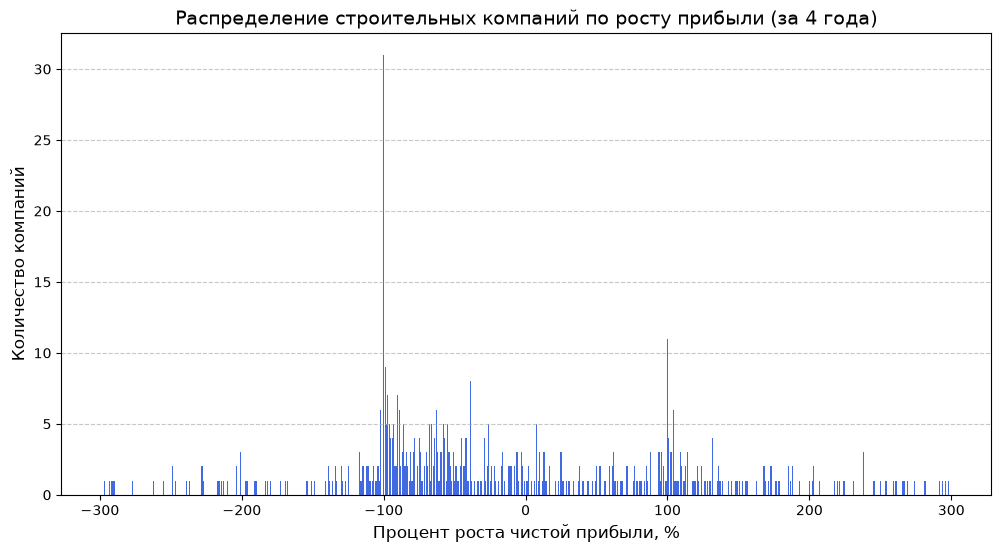

CPU times: total: 359 ms
Wall time: 367 ms


In [ ]:
%%time

N = 4
df_results = analys_for_growth(df_results, N)
counts_data = build_counts_data(df_results, N)

graph_plotting(counts_data, N)

Анализируя гистограму, можно сделать вывод, что сейчас для строительного рынка наступили не лучшие времена. Весомая часть компаний терпит убытки, а пик и вовсе приходится на отрицательный процент роста чистой прибыли(около 30 компаний из 1000).